In [1]:
import numpy as np
import scipy as scy
import torch
import deep_tensor as dt
import matplotlib as mpl
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from torch import Tensor
import math#
import time

from TorchFunctions import *
from CalcMarg import *


make_plots = False

markersize = 3
lWdt = 0.5
alpha = 0.75
PgWidthPt = 421/2
fraction = 1.5
TrueCol = [50/255,220/255, 0/255]#'C2'
binCol = 'C0'
dpi = 300
mpl.rcParams.update(mpl.rcParamsDefault)
plt.rcParams.update({'font.size': 10,#1/0.3 *fraction *
                     'text.usetex': True,
                     'font.family' : 'serif',
                     'font.serif'  : 'cm',
                     'text.latex.preamble': r'\usepackage{bm, amsmath, amssymb,amsfonts}'})


device = 'cuda' if torch.cuda.is_available() else 'cpu'

seed = 12
torch.manual_seed(seed)

## Generate Data from Ground Truth
A stationary satellite in atmosphere is measuring thermal radiation of ozone by pointing through the atmosphere (limb-sounding). The atmosphere is modelled by $n$ layers and the satellite is taking $m$ measurements according to some measurement angles.
<img src="LimbPic.png" alt="LimbPic" width="800"/>\
One data point is caculated as the integral along the path $\Gamma_j$ given by the radiative transfer equation:
$$	 y_j = \int_{\Gamma_j}  B(\nu,T) k(\nu, T)   \frac{p(r)}{k_{\text{B}} T(r)}  x(r)  \tau(r) \text{d}r + \eta_j$$
$$\text{with } \,	\tau(r) = \exp{ \Bigl\{ - \int^{r}_{r_\text{obs}}  k(\nu, T)   \frac{p(r^{\prime})}{k_B T(r^{\prime})}  x(r^{\prime}) \text{d}r^{\prime} \Bigr\} } \, , \eta_j \sim \mathcal{N}(0, \gamma^{-1}) \text{ and } j = 1,\dots,m .$$
Here $T$ is the temperature, $B$ the black body radiation, $k$ is the absorption constant $p$ is the pressure, $x$ is the ozone volume mixing ratio and $\tau$ accounts for the non-linear re absorption.\
Then the noisy data vector is: $$ {\boldsymbol y} = {\boldsymbol A}({\boldsymbol x}) + {\boldsymbol \eta}\, $$

In [2]:
df = np.loadtxt('testProf.txt')
h0 = 11
h1 = 20.1
h2 = 32.3
h3 = 47.4
h4 = 51.4
h5 = 71.8
a0 = -6.5
a1 = 0
a2 = 1
a3 = 2.8
a4 = 0
a5 = -2.8
a6 = -2
b0 = 288.15

tempParams = h0,h1,h2,h3,h4,h5,a0,a1,a2,a3,a4,a5,a6,b0




# load ozone and pressure values
# initiate temperature and height values 
df = np.loadtxt('testProf.txt')
df_pres_val, df_ozon_val = torch.as_tensor(df, dtype=torch.float32)
df_ozon_val[df_ozon_val<0] = 0

df_hei_val, df_temp_val = get_height_temp_from_press(df_pres_val, tempParams)


#set upper and lower index
minInd = 5
maxInd = 50
df_ozon_val = df_ozon_val[minInd:maxInd].clone()
n = df_ozon_val.shape[0]
MinH = df_hei_val[minInd]
MaxH = df_hei_val[maxInd-1]

# interpolate for equidsitance layers
hei_val = torch.linspace(MinH, MaxH, n)
ozon_val = torch.tensor(np.interp(hei_val, df_hei_val[minInd:maxInd], df_ozon_val)).reshape(n, -1)

pres_val, temp_val = get_press_temp_from_height(hei_val, df_pres_val[minInd], tempParams)

hei_val = torch.round(hei_val.reshape(n, -1),decimals=2)
temp_val=  torch.round(temp_val.reshape(n, -1),decimals=2)
pres_val =  pres_val.reshape(n, -1)

if make_plots:
    fig = plt.figure(figsize=plt.figaspect(0.4))
    
    ax = fig.add_subplot(1, 3, 1)
    ax.plot(ozon_val,hei_val,marker = 'o',markerfacecolor = TrueCol, color = TrueCol , label = r'true $\bm{x}$', zorder=1 ,linewidth = 3, markersize =15)
    ax.legend()
    ax.set_xlabel(r'ozone volume mixing ratio')
    ax.set_ylabel(r'height in km')
    ax = fig.add_subplot(1, 3, 2)
    ax.plot(pres_val,hei_val,marker = 'o',markerfacecolor = TrueCol, color = TrueCol , label = r'true $\bm{p}$', zorder=1 ,linewidth = 3, markersize =15)
    ax.legend()
    ax.set_xlabel(r'pressure in hPa')
    
    ax = fig.add_subplot(1, 3, 3)
    ax.plot(temp_val,hei_val,marker = 'o',markerfacecolor = TrueCol, color = TrueCol , label = r'true $\bm{T}$', zorder=1 ,linewidth = 3, markersize =15)
    ax.legend()
    ax.set_xlabel(r'temperature in K')
    plt.show() 


In [3]:

r_earth = 6356#6371 # earth radiusin km
obs_height = 500 # observer height in km

max_ang = torch.arcsin((hei_val[-1]+ r_earth) / (r_earth + obs_height))
min_ang = torch.arcsin((hei_val[0] + r_earth) / (r_earth + obs_height))

##
point_acc = 0.00085
meas_angChosen =torch.arange(min_ang[0], max_ang[0], point_acc)[:30]
org_height_values = torch.clone(hei_val)
org_temp_values = torch.clone(temp_val)
org_pressure_values = torch.clone(pres_val)
org_VMR_O3 = torch.clone(ozon_val)

SNR = 150
ind = 623

noisy_data, noise_free_data, tang_heights, A_param  = gen_data(ozon_val, hei_val, temp_val, pres_val, obs_height, r_earth, meas_angChosen,ind, SNR)


if make_plots:
    fig3, ax1 = plt.subplots(tight_layout = True,figsize=set_size(PgWidthPt, fraction=fraction))
    
    ax1.plot(noise_free_data, tang_heights, color = 'k',marker = 'o', linestyle = '', markersize=3,  label = 'noise-free data', zorder = 1)
    ax1.plot(noisy_data, tang_heights , color = 'r', marker = 'o',  linestyle = '',linewidth = 0.5, markersize=7, label = 'noisy data', zorder = 0)
    
    #ax1.set_xscale('log')
    ax1.legend()
    ax1.set_ylabel(r'tangent height $h_{\ell}$ in km')
    ax1.set_xlabel(r'spectral radiance in $\frac{\text{W} \text{cm}}{\text{m}^2 \text{sr}} $',labelpad=10)# color =dataCol,
    #plt.savefig('TTPapData.png', dpi = dpi)
    plt.show(block=True)

Distance through layers check: True
Targeted frequency 235.71 in GHz
The difference between linear and non linear forward model is approx 1.0%


## Hierarchical Linear Model 
Since the forward model is weakly non-linear we ignore the absorption term $\tau$ and consider the linear model
$$ {\boldsymbol y} = {\boldsymbol A} {\boldsymbol x} + {\boldsymbol \eta} .$$

The hierarchical linear-Gaussian Bayesian model with the unkown parameter ${\boldsymbol x}$ (ozone volumen mixing ratio) and multiple hyper-parameters $ {\boldsymbol \theta}$ is defined as
$$ {\boldsymbol y} | {\boldsymbol x}, {\boldsymbol \theta} \sim \mathcal{N}({\boldsymbol A_{ {\boldsymbol \theta}}} {\boldsymbol x}, {\boldsymbol \Sigma}_{\boldsymbol \theta}) $$
		$${\boldsymbol x} |  {\boldsymbol \theta} \sim \mathcal{N}({\boldsymbol \mu} = {\boldsymbol 0} , {\boldsymbol Q}_{\boldsymbol \theta}^{-1} ) $$
	$$	{\boldsymbol \theta} \sim \pi({\boldsymbol \theta}) $$

Given some data ${\boldsymbol y}$, the goal is to characterise the posterior $$\pi({\boldsymbol x}, {\boldsymbol \theta} |{\boldsymbol y} )  = \pi({\boldsymbol x} |  {\boldsymbol \theta}, {\boldsymbol y} ) \pi(  {\boldsymbol \theta} | {\boldsymbol y} )$$ which can be factorised into the marginal posterior $\pi(  {\boldsymbol \theta} | {\boldsymbol y} )$ and the full conditional $\pi({\boldsymbol x} |  {\boldsymbol \theta}, {\boldsymbol y} )$. To draw samples from the $\{{\boldsymbol x}, {\boldsymbol \theta} \}\sim \pi({\boldsymbol x}, {\boldsymbol \theta} |{\boldsymbol y} ) $ we draw independent samples ${\boldsymbol \theta}\sim \pi(  {\boldsymbol \theta} | {\boldsymbol y} )$ from the marginal posterior first. Then conditioned on an independent hyper-parameter sample one can draw independent ${\boldsymbol x} \sim \pi({\boldsymbol x} |  {\boldsymbol \theta}, {\boldsymbol y} )$.
Consequently we are characterising the marginal posterior first via a tensor-train approximation.
The marginal posterior is: $\pi(  {\boldsymbol \theta} | {\boldsymbol y} ) \propto  \pi({\boldsymbol y} |  {\boldsymbol \theta}  )\pi(  {\boldsymbol \theta} ) $.
For the linear-Gaussian case the  marginal likelihood ${\boldsymbol y}|{\boldsymbol \theta} \sim \mathcal{N}({\boldsymbol A}{\boldsymbol \mu} = {\boldsymbol 0},{\boldsymbol \Sigma}_{{\boldsymbol y}|{\boldsymbol \theta}}  ) \ $ is a normal distribution and $\pi(  {\boldsymbol \theta} )$ is a prior relecting physicaly suitable ranges for the individual hyper-parameters.
The covaricance matrix of the marginal likelihood is $ {\boldsymbol \Sigma}_{{\boldsymbol y}|{\boldsymbol \theta}} = {\boldsymbol \Sigma}_{\boldsymbol \theta} + {\boldsymbol A}_{\boldsymbol \theta} {\boldsymbol Q}_{\boldsymbol \theta}^{-1} {\boldsymbol A}_{\boldsymbol \theta}^T $ $\text{\href{https://en.wikipedia.org/wiki/Woodbury_matrix_identity}{the Woodbury matrix identity}}$ gives $ {\boldsymbol Q}_{{\boldsymbol y}|{\boldsymbol \theta}} = {\boldsymbol \Sigma}_{{\boldsymbol y}|{\boldsymbol \theta}}^{-1} = {\boldsymbol \Sigma}_{\boldsymbol \theta}^{-1} - {\boldsymbol \Sigma}_{\boldsymbol \theta}^{-1} {\boldsymbol A}_{\boldsymbol \theta} ({\boldsymbol Q}_{\boldsymbol \theta} + {\boldsymbol A}_{\boldsymbol \theta}^{T}{\boldsymbol \Sigma}_{\boldsymbol \theta}^{-1} {\boldsymbol A}_{\boldsymbol \theta})^{-1} {\boldsymbol A}_{\boldsymbol \theta}^T {\boldsymbol \Sigma}_{\boldsymbol \theta}^{-1}
$.


To setup the hierarchical Bayesian model we model the smoothness of the ozone profile through the precision matrix $ {\boldsymbol Q}_{\boldsymbol \theta} =\delta {\boldsymbol L}$, where ${\boldsymbol L}$ is a discrete approximation to the second-order derivative.
The larger spacing between higher atmospheric layers introduces stronger correlation between ozone values in the upper atmosphere.
Further we describe the pressure profile as an exponential with 2 hyper-parameters and the temperature profile with 14 hyper-parameters.
The noise precision $\gamma$ and the ozone smoothnes $\delta$ are also classified as hyper-parameters.
The hyper-priors for $\gamma$ and $\delta$ are chosen to be gamma distributions and for the pressure and temperature realted hyper-parameters are chosen to be normal distributions.

In [5]:
## new forwrad model
startInd = 23
EndInd = len(org_height_values[startInd::2]) + startInd 

height_values = torch.clone(org_height_values)
temp_values = torch.clone(org_temp_values)
pressure_values = torch.clone(org_pressure_values)

height_values[startInd:EndInd] = torch.clone(org_height_values[startInd::2])
height_values = torch.clone(height_values[:EndInd])

temp_values[startInd:EndInd] = torch.clone(org_temp_values[startInd::2])
temp_values = torch.clone(temp_values[:EndInd])

pressure_values[startInd:EndInd] = torch.clone(org_pressure_values[startInd::2])
pressure_values = torch.clone(pressure_values[:EndInd])

VMR_O3 = torch.clone(org_VMR_O3)
VMR_O3[startInd:EndInd] = torch.clone(org_VMR_O3[startInd::2])
VMR_O3 = torch.clone(VMR_O3[:EndInd])

## SpecNumLayers = len(height_values)
n =len(height_values)

upL = torch.triu(-1*torch.ones((len(VMR_O3),len(VMR_O3))),1) - torch.triu(-1*torch.ones((len(VMR_O3),len(VMR_O3))),2)
lowL =  torch.tril(-1*torch.ones((len(VMR_O3),len(VMR_O3))),-1) - torch.tril(-1*torch.ones((len(VMR_O3),len(VMR_O3))),-2)
diagL = torch.diag(2*torch.ones(len(VMR_O3)))

L = diagL + lowL + upL
lowC_L = torch.linalg.cholesky(L,upper=False)

##
A_lin_dx, tang_heights_lin, extraHeight = torch_gen_forward_map(meas_angChosen,height_values,obs_height,r_earth)
A_lin = torch_gen_sing_map(A_lin_dx, tang_heights_lin, height_values)

#AO3, theta_scale_O3 = torch_composeAforO3(A_lin, temp_values, pressure_values, *A_param)
#A = 2*AO3
#ATA = torch.matmul(A.T,A)
#ATy = torch.matmul(A.T, noisy_data)
#linDat = A @ VMR_O3

def pressFunc(x, b, p0):
    return np.exp(-b * x  + np.log(p0))
popt, pcov = scy.optimize.curve_fit(pressFunc, height_values[:,0], pressure_values[:,0], p0=[1.5e-1, pressure_values[0,0]])


# Grid
gridSize = 30#150#15
factor = 3.75#1.5
dim = 18
GamBounds = [0.8e15, 0.9e16]
LambBounds = [1e-5, 0.8e-4]
means = torch.tensor([popt[0],h0,b0,popt[1],h2,a1,h1,a0,a2,a3,h3,a4,h4,a5,h5,a6])
sigmas = torch.tensor([0.0001*100,1.5,10,20,2.5,0.1,0.7,0.01,0.01,0.1,0.5,0.1,0.5,0.1,3,0.01 ])

univarGridFull = [torch.linspace(*GamBounds , gridSize),
                torch.linspace(5e10,10e12, gridSize),
                torch.linspace(means[0] - sigmas[0] * 1.2*factor, means[0] + sigmas[0] * factor, gridSize),
                torch.linspace(means[1] - sigmas[1]  * factor, means[1] + sigmas[1]  * factor, gridSize),
                torch.linspace(means[2] - sigmas[2] * 1.1*factor, means[2] + sigmas[2] * factor, gridSize),
                torch.linspace(means[3] - sigmas[3] *factor, means[3] + sigmas[3]* factor, gridSize),
                torch.linspace(means[4] - sigmas[4]  * factor, means[4] + sigmas[4] * factor, gridSize),
                torch.linspace(means[5] - sigmas[5] * factor, means[5] + sigmas[5] * factor, gridSize),
                torch.linspace(means[6] - sigmas[6] *1.1* factor, means[6] + sigmas[6] *factor, gridSize),
                torch.linspace(means[7] - sigmas[7] * factor, means[7] + sigmas[7] * factor, gridSize),
                torch.linspace(means[8] - sigmas[8] * factor, means[8] + sigmas[8] * factor, gridSize),
                torch.linspace(means[9] - sigmas[9] * factor, means[9] + sigmas[9] * factor, gridSize),
                torch.linspace(means[10] - sigmas[10] * factor, means[10] + sigmas[10] * factor, gridSize),
                torch.linspace(means[11] - sigmas[11] * factor, means[11] + sigmas[11] * factor, gridSize),
                torch.linspace(means[12] - sigmas[12] * factor, means[12] + sigmas[12] * factor, gridSize),
                torch.linspace(means[13]- sigmas[13]* factor, means[13]+ sigmas[13] * factor, gridSize),
                torch.linspace(means[14] - sigmas[14] * factor, means[14] + sigmas[14] * factor, gridSize),
                torch.linspace(means[15]- sigmas[15]  * factor, means[15]+ sigmas[15] * factor, gridSize)]

# draw parameter tensor from grid

#randInt = torch.randint(low=0, high = gridSize, size = (100,dim))
#randParam = torch.empty(size = randInt.size())
#for d in range(0,dim):
#    randParam[:,d] = univarGridFull[d][randInt[:,d]]

# compute torch_marg_post value
neg_log_torch_marg_post = lambda params: -torch_marg_post(params, height_values, torch.eye(noisy_data.shape[0]), 2*A_lin, A_param , L,noisy_data,means,sigmas )

#randVal = neg_log_torch_marg_post(randParam)

In [6]:
reference = dt.UniformReference() # define reference measure
# here you can choose different reference measure e.g. Gaussian

dim = len(univarGridFull)
bounds = torch.zeros(size = [dim,2])
for i in range(0,dim):
    #currGrid = torch.tensor(np.copy(univarGridFull[i]))
    currGrid = univarGridFull[i]
    bounds[i,0] = currGrid[0]
    bounds[i,1] = currGrid[-1]

approximation_domain = bounds # set grid boundaries
preconditioner = dt.UniformMapping(approximation_domain, reference) # define preconditioner

#dim = 2  # dimension of target density
basis = dt.Lagrange1(num_elems=29) # this is 30 gridpoints piecewise linear interpolation
# here you can choose other interpolation basis such as fourier or chebyshev
bases = dt.ApproxBases(basis, dim) # set bases

# may adjust earlier set options such as ranks number of sweep or allow increase of rank by not specifying tt_method="fixed_rank"
tt_options = dt.TTOptions(max_als=1, init_rank=10, tt_method="fixed_rank") # set number of sweeps (max_als=1), ranks, fix ranks
#tt_options = dt.TTOptions(max_als=1, init_rank=10)
tt = dt.TT(tt_options)
ftt = dt.FTT(bases, tt,num_error_samples=0)
neg_log_torch_marg_post = lambda params: -torch_marg_post(params,  height_values, torch.eye(noisy_data.shape[0]), 2*A_lin,A_param , L,noisy_data,means,sigmas) 

# defined above
target_func = dt.TargetFunc(neg_log_torch_marg_post) # set target function
bridge = dt.SingleLayer()  # set single-layer DIRT (i.e., SIRT)
# do DIRT (layered) as  : dirt = dt.DIRT(target_func, preconditioner, ftt)#, bridge) # do single-layer DIRT (i.e., SIRT)
sirt_options = dt.DIRTOptions(num_error_samples=0)
sirt = dt.DIRT(target_func, preconditioner, ftt ,bridge, sirt_options)

[DIRT] Iter:  1 | Cum. Fevals: 0.00e+00 | Cum. Time: 2.15e-06 s
[ALS]  Iter | Func Evals | Max Rank | Max Core Error | Mean Core Error | L2 Error
[ALS]     1 |      49600 |       10 |       1.00e+00 |        1.00e+00 | 4.35e-02
[ALS]  ALS complete.
[DIRT] DIRT construction complete.
[DIRT]  • Layers: 1.
[DIRT]  • Total function evaluations: 49,600.
[DIRT]  • Total time: 44.10 secs.


In [7]:
startTime = time.time()
extraSampl = 100
numRTOSampl = 1000
num_sampl = numRTOSampl * 2 + extraSampl
# Draw a set of uniform random samples
rs = reference.random(n=num_sampl , d=dim)

# Transform the samples according to SIRT approximation
xs, neglogfxs_sirt = sirt.eval_irt(rs)
# Compute potential function of the (unnormalised) target density at each SIRT sample
neglogfxs_exact = target_func(xs)
res = dt.run_independence_sampler(xs, neglogfxs_sirt, neglogfxs_exact)
print(f'Time to gernerate {num_sampl} samples: {(time.time()-startTime):.2f}s')

print(f"Acceptance rate: {res.acceptance_rate:.3f}")
#for i in range(0,dim):
    #print(f"IACT (x{i}): {res.iacts[i]:.3f}")

# autocorrelation time with Ulli Wollf
from puwr import tauint
import numpy as np
Uwerrtint = np.zeros(dim)
Uwerrd_tint = np.zeros(dim)
for i in range(0,dim):
    Uwerrmean, Uwerr, Uwerrtint[i], Uwerrd_tint[i] = tauint([[np.array(res.xs[:,i])]], f =  0)
    #print(f'IATC of (x{i}) is: {2* Uwerrtint[i]:.2f} \u00B1 {2*Uwerrd_tint[i]:.2f}')
max_IACT = np.max(Uwerrtint)
print(f'The maximum IACT is {2*max_IACT:.2f} \u00B1 {2*Uwerrd_tint[Uwerrtint==max_IACT][0]:.2f}')

Time to gernerate 2100 samples: 2.04s
Acceptance rate: 0.947
The maximum IACT is 1.54 ± 0.13


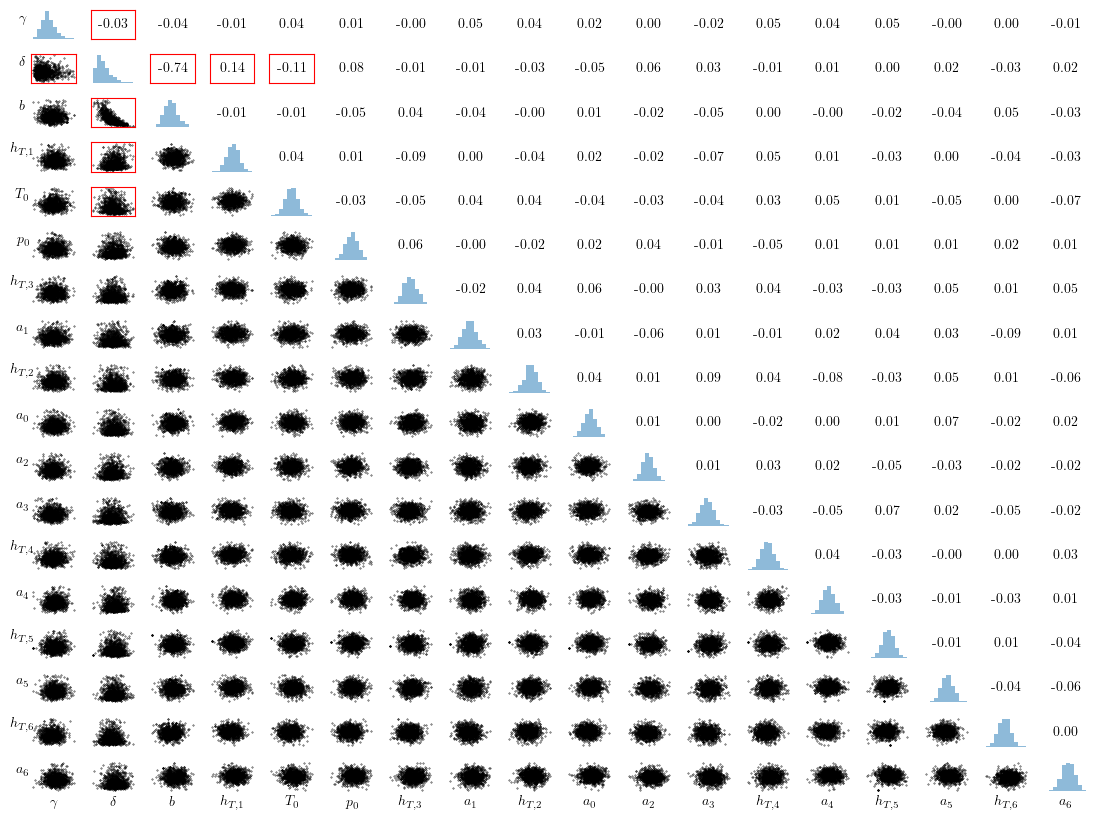

In [8]:

labels = [r'$\gamma$',r'$\delta$',r'$b$',r'$h_{T,1}$',r'$T_0$',r'$p_0$',r'$h_{T,3}$',r'$a_1$',r'$h_{T,2}$',r'$a_0$',r'$a_2$',r'$a_3$',r'$h_{T,4}$',r'$a_4$',r'$h_{T,5}$',r'$a_5$',r'$h_{T,6}$',r'$a_6$']
dpi = 300
alpha = 0.5

fig, axs = plt.subplots(18, 18, figsize = (800/ 72.27, 600/ 72.27), tight_layout = True)
for i in range(0, 18):
    axs[i, i].hist(res.xs[::2,i], alpha=alpha)
    for j in range(0, 18):
        if j < i:
            axs[i,j].scatter(res.xs[::2,i],res.xs[::2,j],  s = 0.1, color = 'k' )
            axs[j, i].text(0.5, 0.5,f'{scy.stats.pearsonr(res.xs[::2,i],res.xs[::2,j])[0]:.2f}',
                           horizontalalignment='center',
                           verticalalignment='center',
                           transform=axs[j, i].transAxes)

        axs[i, j].spines['top'].set_visible(False)
        axs[i, j].spines['right'].set_visible(False)
        axs[i, j].spines['bottom'].set_visible(False)
        axs[i, j ].spines['left'].set_visible(False)
        axs[i, j].tick_params(axis='both', which='both', bottom=False, top=False, labelbottom=False, labelleft=False, left=False)

for i in range(0, 18):
    axs[i, 0].set_ylabel(str(labels[i]), rotation=0)
    axs[i, 0].yaxis.set_label_coords(-0.2, 0.5)

for j in range(0, 18):
    axs[-1,j].set_xlabel(labels[j])

j = 1
i = 0
for i in range(0, 18):
    for j in range(0, 9):
        if ((i == 1 and j == 0)
                or (i == 0 and j == 1)
        or (i == 2 and j == 1) or (i == 1 and j == 2)
        or (i == 3 and j == 1) or (i == 1 and j == 3)
        or (i == 4 and j == 1) or (i == 1 and j == 4)):
            axs[i, j].spines['top'].set_visible(True)
            axs[i, j].spines['right'].set_visible(True)
            axs[i, j].spines['bottom'].set_visible(True)
            axs[i, j].spines['left'].set_visible(True)
            axs[i, j].spines['bottom'].set_color('r')
            axs[i, j].spines['top'].set_color('r')
            axs[i, j].spines['left'].set_color('r')
            axs[i, j].spines['right'].set_color('r')
            
plt.show(block = True)

## Randomise then Optimise (RTO) to draw Samples from the full conditional
The full conditional
$$
	{\boldsymbol x} | {\boldsymbol \theta} , {\boldsymbol y}\sim \mathcal{N}\Big(\big({\boldsymbol Q}_{\boldsymbol \theta}+ {\boldsymbol A}_{\boldsymbol \theta}^T {\boldsymbol \Sigma}_{\boldsymbol \theta}^{-1} {\boldsymbol A}_{\boldsymbol \theta} \big)^{-1} {\boldsymbol A}_{\boldsymbol \theta}^T {\boldsymbol \Sigma}_{\boldsymbol \theta}^{-1} {\boldsymbol y} , \big({\boldsymbol Q}_{\boldsymbol \theta} + {\boldsymbol A}_{\boldsymbol \theta}^T {\boldsymbol \Sigma}_{\boldsymbol \theta}^{-1} {\boldsymbol A}_{\boldsymbol \theta}\big)^{-1} \Big)\,$$ is a normal distribution. The RTO utelises the structure of the hierarchical model and one independet samples can be generated by solving $$	\left( {\boldsymbol A}_{{\boldsymbol \theta}}^T {\boldsymbol \Sigma}^{-1}_{\gamma} {\boldsymbol A}_{{\boldsymbol \theta}} + {\boldsymbol Q}_{\delta} \right) {\boldsymbol x}^{(k)} ={\boldsymbol A}_{{\boldsymbol \theta}}^T {\boldsymbol \Sigma}^{-1}_{\gamma} {\boldsymbol y} + {\boldsymbol Q}_{\delta} {\boldsymbol \mu} + \sqrt{\gamma}{\boldsymbol A}_{{\boldsymbol \theta}}^T {\boldsymbol v}_1 + \sqrt{\delta}\sqrt{{\boldsymbol L}}{\boldsymbol v}_2,
$$
where ${\boldsymbol v}_1 \sim \mathcal{N}({\boldsymbol 0}, {\boldsymbol I}_n)$ and ${\boldsymbol v}_2 \sim \mathcal{N}({\boldsymbol 0}, {\boldsymbol I}_m)$ representing Gaussian random variables and $\sqrt{{\boldsymbol L}}$ is the cholesky factor of ${\boldsymbol L}$

Time do draw 1000 full conditional samples via the RTO method: 0.89s


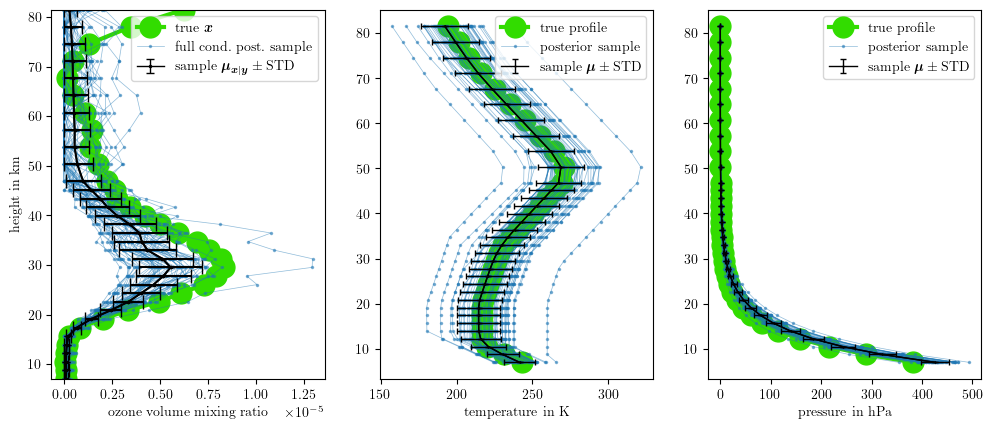

In [56]:

RTO_start = time.time()
O3_sampl = torch.zeros((numRTOSampl,n))
P_sampl= torch.zeros((numRTOSampl,n))
T_sampl= torch.zeros((numRTOSampl,n))
cholesky_L = torch.linalg.cholesky(L)
     
for i in range(0,numRTOSampl):
    curr_ind = i*2 
    ind_smapl = res.xs[curr_ind]
    O3_sampl[i], P_sampl[i] , T_sampl[i] = torch_RTO(2*A_lin, noisy_data ,  torch.eye(noisy_data.shape[0]),cholesky_L, L, ind_smapl, height_values,  A_param)
    O3_sampl[i][O3_sampl[i] < 0] =  0

RTO_elaps = time.time()
print(f'Time do draw {numRTOSampl} full conditional samples via the RTO method: {(RTO_elaps-RTO_start):.2f}s')
PostO3Mean =  torch.mean(O3_sampl, axis = 0)
PostO3Var = torch.var(O3_sampl, axis = 0)
lower_error = torch.sqrt(PostO3Var)
upper_error = torch.sqrt(PostO3Var)
lower_error[(PostO3Mean - lower_error) < 0] =  PostO3Mean[(PostO3Mean- lower_error) < 0]
lower_error[PostO3Mean < 0] =  0
asymmetric_error = np.array(list(zip(lower_error, upper_error))).T

numSamplPlots = 50
if make_plots:
    fig = plt.figure(figsize=plt.figaspect(0.4))
    
    ax1 = fig.add_subplot(1, 3, 1)
    ax1.plot(VMR_O3 ,height_values[:,0],marker = 'o',markerfacecolor = TrueCol, color = TrueCol , label = r'true $\bm{x}$', zorder=0 ,linewidth = 3, markersize =15)
    ax1.plot(O3_sampl[0], height_values, markeredgecolor=binCol, color=binCol, alpha = alpha,zorder=1, marker='.', markersize=markersize,linewidth=lWdt, label = 'full cond.~post.~sample')
    
    for i in range(1,numSamplPlots):
        ax1.plot(O3_sampl[i], height_values, markeredgecolor=binCol, color=binCol, alpha = alpha,zorder=1, marker='.', markersize=markersize,linewidth=lWdt)
    
    ax1.errorbar(PostO3Mean,height_values[:,0],xerr =asymmetric_error, markeredgecolor ='k', color = 'k' ,zorder=3, marker = '.', markersize =3, linewidth =1.5, capsize = 5)#, markerfacecolor = 'none'
    ax1.errorbar(PostO3Mean,height_values[:,0],  yerr = np.zeros(len(height_values)), markeredgecolor ='k', color = 'k' ,zorder=3, marker = '.', label = r'sample $\bm{\mu}_{\bm{x}|\bm{y}} \pm \text{STD}$', markersize =3, linewidth =1, capsize = 3)
    
    ax1.set_xlabel(r'ozone volume mixing ratio')
    ax1.set_ylabel('height in km')
    handles, labels = ax1.get_legend_handles_labels()
    ax1.set_ylim([height_values[0], height_values[-1]])
    ax1.legend(loc = 'upper right')


    
    axs = fig.add_subplot(1, 3, 2)
    axs.plot( temp_values,height_values,marker = 'o',markerfacecolor = TrueCol, color = TrueCol , label = 'true profile', zorder=0 ,linewidth = 3, markersize =15)
    
    axs.errorbar( torch.mean(T_sampl, axis = 0) ,height_values, xerr = torch.sqrt(torch.var(T_sampl, axis = 0)), markeredgecolor ='k', color = 'k' ,zorder=2, marker = '.', markersize =1, linewidth =1, capsize = 2)
    axs.errorbar( torch.mean(T_sampl, axis = 0) ,height_values[:, 0], yerr =torch.zeros(len(height_values)), markeredgecolor ='k', color ='k' ,zorder=2, marker = '.', label = r'sample $\bm{\mu} \pm \text{STD}$ ',  markersize =1, linewidth =1, capsize = 2)
    
    
    axs.plot(T_sampl[0], height_values, markeredgecolor=binCol, color=binCol, alpha = alpha,zorder=1, marker='.', markersize=markersize, linewidth=lWdt, label='posterior sample')
    
    for i in range(1, numSamplPlots):
        axs.plot(T_sampl[i], height_values, markeredgecolor=binCol, color=binCol,alpha = alpha, zorder=1, marker='.', markersize=markersize, linewidth=lWdt)
    
    #h, l = axs.get_legend_handles_labels()
    #axs.legend(np.append(h[:2],h[-1]), np.append(l[:2],l[-1]))
    axs.legend()
    axs.set_xlabel(r'temperature in K ')
    
    #axs.set_ylabel(r'height in km')
    
    axs = fig.add_subplot(1, 3, 3)
    axs.plot( pressure_values,height_values,marker = 'o',markerfacecolor = TrueCol, color = TrueCol , label = 'true profile', zorder=0 ,linewidth =3, markersize =15)
    axs.errorbar( torch.mean(P_sampl, axis = 0) ,height_values, xerr = torch.sqrt(torch.var(P_sampl, axis = 0)), markeredgecolor ='k', color = 'k' ,zorder=2, marker = '.', markersize =1, linewidth =1, capsize = 2)
    axs.errorbar( torch.mean(P_sampl, axis = 0) ,height_values[:, 0], yerr =torch.zeros(len(height_values)), markeredgecolor ='k', color ='k' ,zorder=2, marker = '.', label = r'sample $\bm{\mu} \pm \text{STD}$ ',  markersize =1, linewidth =1, capsize = 2)
    
    axs.plot(P_sampl[0], height_values, markeredgecolor=binCol, color=binCol, alpha = alpha, zorder=1, marker='.', markersize=markersize, linewidth=lWdt, label='posterior sample')
    
    for i in range(1,numSamplPlots):
        axs.plot(P_sampl[i], height_values, markeredgecolor=binCol, color=binCol,  alpha = alpha, zorder=1, marker='.', markersize=markersize, linewidth=lWdt)
    
    #h, l = axs.get_legend_handles_labels()
    axs.legend()
    axs.set_xlabel(r'pressure in hPa')
    
    #axs.set_ylabel(r'height in km')
    plt.show() 

## Find Affine Map

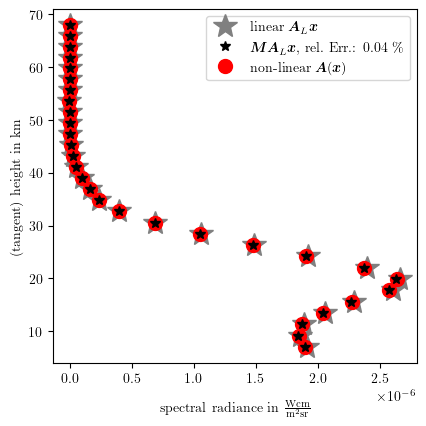

In [23]:
m = noisy_data.shape[0]
files = '634f1dc4.par' 
wvnmbr, S, F, g_air, g_self, E, n_air, g_doub_prime, g_prime = load_hitran_param(files)

nonLinDat = torch.zeros((numRTOSampl,m))
LinDat =  torch.zeros((numRTOSampl,m))

for i in range(0,numRTOSampl):
    CalcA, theatscale = torch_composeAforO3(A_lin, T_sampl[i].reshape((n,1)), P_sampl[i].reshape((n,1)), *A_param)
    nonLinA = torch_calcNonLin(tang_heights_lin, A_lin_dx, height_values, P_sampl[i].reshape((n,1)), ind, T_sampl[i].reshape((n,1)),  O3_sampl[i].reshape((n,1)), wvnmbr, S, E,g_doub_prime,g_prime)
    LinDat[i] = (2*CalcA @ O3_sampl[i].reshape((n,1)))[:,0]
    nonLinDat[i] = ((nonLinA*CalcA) @ O3_sampl[i].reshape((n,1)))[:,0] 

Map = torch.zeros((m,m))
#solution = torch.linalg.lstsq(LinDat,nonLinDat).solution
for i in range(0,m):
    solution = torch.linalg.lstsq(LinDat,nonLinDat[:,i])
    #solution[1]= torch.tensor(2)
    if solution[1].numel()== True:
        print('least square solutions b not empty')
    Map[i,:] = solution[0]

# calc over all rel L2 norm error
mappedLinDat = torch.zeros(LinDat.shape)
for i in range(0,numRTOSampl):
    mappedLinDat[i] = Map @ LinDat[i]
    

#relErr = np.sqrt(torch.sum((nonLinDat-mappedLinDat)**2)/torch.sum((nonLinDat)**2))*100
#print(relErr)
#get random sample from marginal posterior and then full conditional posterior via RTO


testInd  = torch.randint(low=numRTOSampl * 2, high = num_sampl, size = [1,1])[0,0]
indTestSmapl = res.xs[testInd]
test_O3_sampl, test_P_sampl , test_T_sampl = torch_RTO(2*A_lin,noisy_data ,  torch.eye(noisy_data.shape[0]), cholesky_L, L, indTestSmapl, height_values,  A_param)

test_A, theatscale = torch_composeAforO3(A_lin, test_T_sampl.reshape((n,1)), test_P_sampl.reshape((n,1)), *A_param)
test_non_lin_A = torch_calcNonLin(tang_heights_lin, A_lin_dx, height_values, test_P_sampl.reshape((n,1)), ind, test_T_sampl.reshape((n,1)),  test_O3_sampl.reshape((n,1)), wvnmbr, S, E,g_doub_prime,g_prime)

lin_test_dat = (2*test_A @ test_O3_sampl.reshape((n,1)))[:,0]
map_lin_test_dat =  Map @ (2*test_A @ test_O3_sampl.reshape((n,1)))[:,0]
non_lin_test_dat = ((test_non_lin_A*test_A) @ test_O3_sampl.reshape((n,1)))[:,0] 


fig4, ax4 = plt.subplots(figsize=set_size(PgWidthPt, fraction=fraction), tight_layout = True)
ax4.plot(lin_test_dat,tang_heights_lin, linestyle = '', marker = '*', label = r'linear $\bm{A}_L\bm{x}$', markersize = 18 , zorder = 0, color = 'gray' )
relErr = np.linalg.norm( map_lin_test_dat -  non_lin_test_dat) / np.linalg.norm(map_lin_test_dat) * 100
ax4.plot(map_lin_test_dat,tang_heights_lin, linestyle = '', marker = '*', label = r'$\bm{MA}_L\bm{x}$' + f', rel.~Err.: {relErr:.2f} \%', markersize = 7, zorder = 2, color ='k')
ax4.plot(non_lin_test_dat,tang_heights_lin, linestyle = '', marker = 'o', label = r'non-linear $\bm{A}(\bm{x})$', markersize = 10, zorder = 1, color = 'r')
ax4.legend()
ax4.set_ylabel('(tangent) height in km')
ax4.set_xlabel(r'spectral radiance in $\frac{\text{W} \text{cm}}{\text{m}^2 \text{sr}} $',labelpad=10)
#plt.savefig('TTPapAssMap.png', dpi = dpi)
plt.show(block= True)

## Use affine approximation to non-linear forward model

In [24]:
new_A_lin = Map @ (2*A_lin)

In [25]:
reference = dt.UniformReference() # define reference measure
# here you can choose different reference measure e.g. Gaussian

print(len(univarGridFull))
dim = len(univarGridFull)
bounds = torch.zeros(size = [dim,2])
for i in range(0,dim):
    #currGrid = torch.tensor(np.copy(univarGridFull[i]))
    currGrid = univarGridFull[i]
    bounds[i,0] = currGrid[0]
    bounds[i,1] = currGrid[-1]

approximation_domain = bounds # set grid boundaries
preconditioner = dt.UniformMapping(approximation_domain, reference) # define preconditioner

#dim = 2  # dimension of target density
basis = dt.Lagrange1(num_elems=29) # this is 30 gridpoints piecewise linear interpolation

# here you can choose other interpolation basis such as fourier or chebyshev
bases = dt.ApproxBases(basis, dim) # set bases

# may adjust earlier set options such as ranks number of sweep or allow increase of rank by not specifying tt_method="fixed_rank"
tt_options = dt.TTOptions(max_als=1, init_rank=10, tt_method="fixed_rank") # set number of sweeps (max_als=1), ranks, fix ranks
#tt_options = dt.TTOptions(max_als=1, init_rank=10)
tt = dt.TT(tt_options)
ftt = dt.FTT(bases, tt,num_error_samples=0)
neg_log_torch_marg_post = lambda params: -torch_marg_post(params, height_values, torch.eye(noisy_data.shape[0]), new_A_lin, A_param , L, noisy_data,means, sigmas) 

# defined above
target_func = dt.TargetFunc(neg_log_torch_marg_post) # set target function
bridge = dt.SingleLayer()  # set single-layer DIRT (i.e., SIRT)
# do DIRT (layered) as  : dirt = dt.DIRT(target_func, preconditioner, ftt)#, bridge) # do single-layer DIRT (i.e., SIRT)
sirt_options = dt.DIRTOptions(num_error_samples=0)
sirt = dt.DIRT(target_func, preconditioner, ftt ,bridge, sirt_options)

18
[DIRT] Iter:  1 | Cum. Fevals: 0.00e+00 | Cum. Time: 2.15e-06 s
----
torch.Size([1000])
[ALS]  Iter | Func Evals | Max Rank | Max Core Error | Mean Core Error | L2 Error
----
torch.Size([300])
----
torch.Size([3000])
----
torch.Size([3000])
----
torch.Size([3000])
----
torch.Size([3000])
----
torch.Size([3000])
----
torch.Size([3000])
----
torch.Size([3000])
----
torch.Size([3000])
----
torch.Size([3000])
----
torch.Size([3000])
----
torch.Size([3000])
----
torch.Size([3000])
----
torch.Size([3000])
----
torch.Size([3000])
----
torch.Size([3000])
----
torch.Size([3000])
----
torch.Size([300])
[ALS]     1 |      49600 |       10 |       1.00e+00 |        1.00e+00 | 5.34e-01
[ALS]  ALS complete.
[DIRT] DIRT construction complete.
[DIRT]  • Layers: 1.
[DIRT]  • Total function evaluations: 49,600.
[DIRT]  • Total time: 46.02 secs.


In [28]:
startTime = time.time()
sec_num_sampl = 20_00
# Draw a set of uniform random samples
rs = reference.random(n=sec_num_sampl , d=dim)

# Transform the samples according to SIRT approximation
xs, neglogfxs_sirt = sirt.eval_irt(rs)
# Compute potential function of the (unnormalised) target density at each SIRT sample
neglogfxs_exact = target_func(xs)
res = dt.run_independence_sampler(xs, neglogfxs_sirt, neglogfxs_exact)
print(f'Time to gernerate {num_sampl} samples: {(time.time()-startTime):.2f}s')

print(f"Acceptance rate: {res.acceptance_rate:.3f}")
#for i in range(0,dim):
#    print(f"IACT (x{i}): {res.iacts[i]:.3f}")

# autocorrelation time with Ulli Wollf
from puwr import tauint
import numpy as np
Uwerrtint = np.zeros(dim)
Uwerrd_tint = np.zeros(dim)
for i in range(0,dim):
    Uwerrmean, Uwerr, Uwerrtint[i], Uwerrd_tint[i] = tauint([[np.array(res.xs[:,i])]], f =  0)
    #print(f'IATC of (x{i}) is: {2* Uwerrtint[i]:.2f} \u00B1 {2*Uwerrd_tint[i]:.2f}')

max_IACT = np.max(Uwerrtint)

print(f'The maximum IACT is {2*Uwerrtint[Uwerrtint==max_IACT][0]:.2f} \u00B1 {2*Uwerrd_tint[Uwerrtint==max_IACT][0]:.2f}')

----
torch.Size([2000])
Time to gernerate 2100 samples: 1.92s
Acceptance rate: 0.945
The maximum IACT is 1.52 ± 0.13


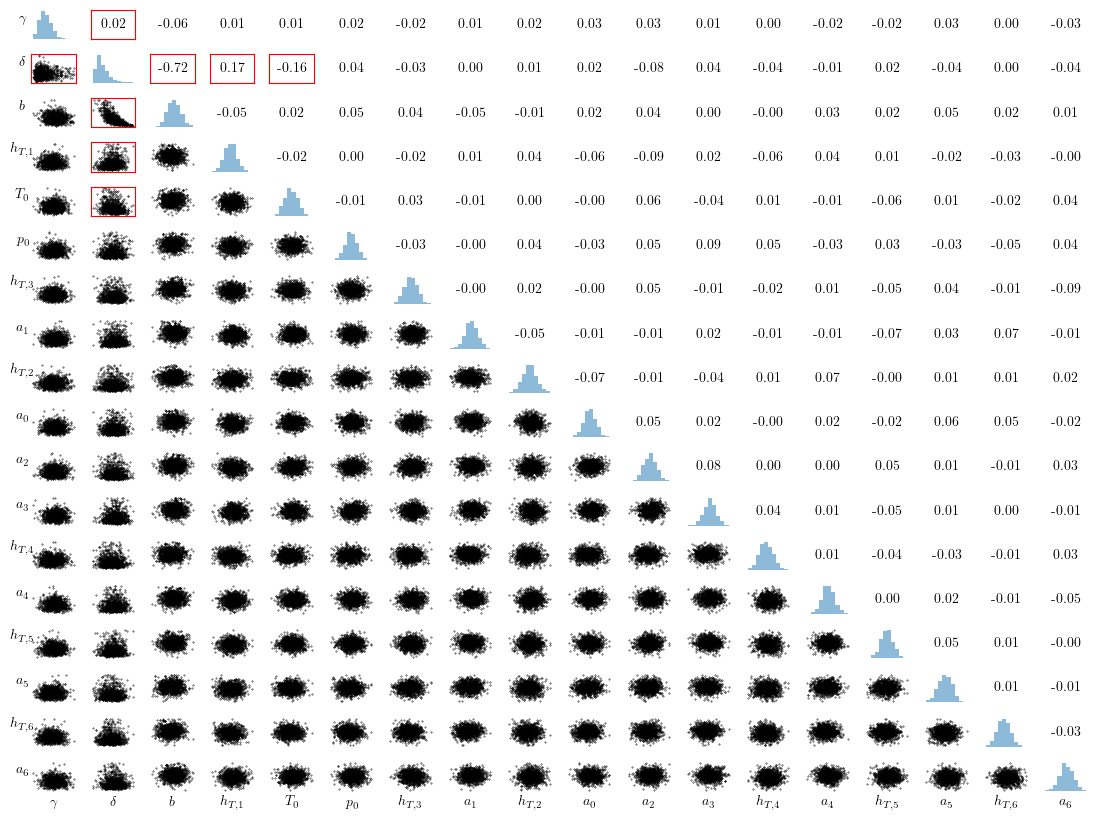

In [29]:

labels = [r'$\gamma$',r'$\delta$',r'$b$',r'$h_{T,1}$',r'$T_0$',r'$p_0$',r'$h_{T,3}$',r'$a_1$',r'$h_{T,2}$',r'$a_0$',r'$a_2$',r'$a_3$',r'$h_{T,4}$',r'$a_4$',r'$h_{T,5}$',r'$a_5$',r'$h_{T,6}$',r'$a_6$']
dpi = 300
alpha = 0.5

fig, axs = plt.subplots(18, 18, figsize = (800/ 72.27, 600/ 72.27), tight_layout = True)
for i in range(0, 18):
    axs[i, i].hist(res.xs[::2,i], alpha=alpha)
    for j in range(0, 18):
        if j < i:
            axs[i,j].scatter(res.xs[::2,i],res.xs[::2,j],  s = 0.1, color = 'k' )
            axs[j, i].text(0.5, 0.5,f'{scy.stats.pearsonr(res.xs[::2,i],res.xs[::2,j])[0]:.2f}',
                           horizontalalignment='center',
                           verticalalignment='center',
                           transform=axs[j, i].transAxes)

        axs[i, j].spines['top'].set_visible(False)
        axs[i, j].spines['right'].set_visible(False)
        axs[i, j].spines['bottom'].set_visible(False)
        axs[i, j ].spines['left'].set_visible(False)
        axs[i, j].tick_params(axis='both', which='both', bottom=False, top=False, labelbottom=False, labelleft=False, left=False)

for i in range(0, 18):
    axs[i, 0].set_ylabel(str(labels[i]), rotation=0)
    axs[i, 0].yaxis.set_label_coords(-0.2, 0.5)

for j in range(0, 18):
    axs[-1,j].set_xlabel(labels[j])

j = 1
i = 0
for i in range(0, 18):
    for j in range(0, 9):
        if ((i == 1 and j == 0)
                or (i == 0 and j == 1)
        or (i == 2 and j == 1) or (i == 1 and j == 2)
        or (i == 3 and j == 1) or (i == 1 and j == 3)
        or (i == 4 and j == 1) or (i == 1 and j == 4)):
            axs[i, j].spines['top'].set_visible(True)
            axs[i, j].spines['right'].set_visible(True)
            axs[i, j].spines['bottom'].set_visible(True)
            axs[i, j].spines['left'].set_visible(True)
            axs[i, j].spines['bottom'].set_color('r')
            axs[i, j].spines['top'].set_color('r')
            axs[i, j].spines['left'].set_color('r')
            axs[i, j].spines['right'].set_color('r')





plt.show(block = True)


## Use Marginal Posterior Samples and RTO to generate Posterior Ozone, Temperature and Pressure Profiles

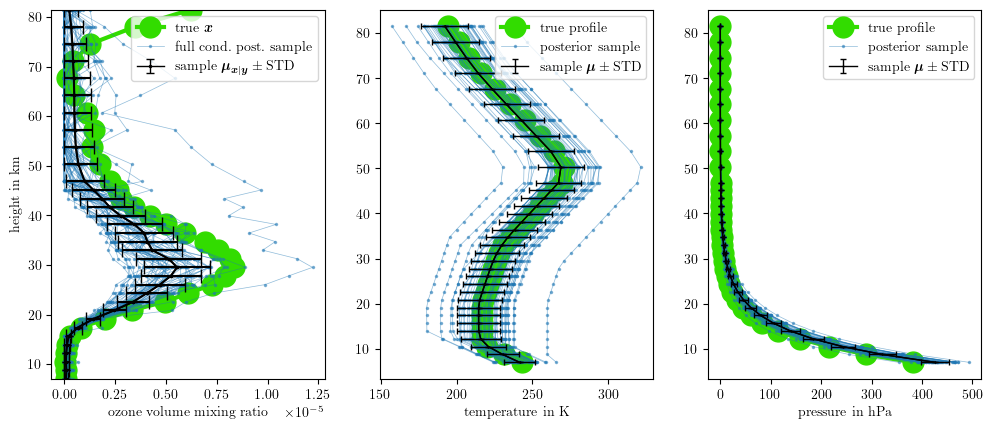

In [30]:


# assume every second TT sample is an independent sample
numRTOSampl = 1000

O3_sampl = torch.zeros((numRTOSampl,n))
P_sampl= torch.zeros((numRTOSampl,n))
T_sampl= torch.zeros((numRTOSampl,n))
for i in range(0,numRTOSampl):
    curr_ind = i*2 
    ind_smapl = res.xs[curr_ind]
    O3_sampl[i], P_sampl[i] , T_sampl[i] = torch_RTO(2*A_lin,noisy_data , Map, cholesky_L, L, ind_smapl, height_values,  A_param)
    O3_sampl[i][O3_sampl[i] < 0] =  0


PostO3Mean =  torch.mean(O3_sampl, axis = 0)
PostO3Var = torch.var(O3_sampl, axis = 0)
lower_error = torch.sqrt(PostO3Var)
upper_error = torch.sqrt(PostO3Var)
lower_error[(PostO3Mean - lower_error) < 0] =  PostO3Mean[(PostO3Mean- lower_error) < 0]
lower_error[PostO3Mean < 0] =  0
asymmetric_error = np.array(list(zip(lower_error, upper_error))).T


if make_plots:
    fig = plt.figure(figsize=plt.figaspect(0.4))
    
    ax1 = fig.add_subplot(1, 3, 1)
    ax1.plot(VMR_O3 ,height_values[:,0],marker = 'o',markerfacecolor = TrueCol, color = TrueCol , label = r'true $\bm{x}$', zorder=0 ,linewidth = 3, markersize =15)
    ax1.plot(O3_sampl[0], height_values, markeredgecolor=binCol, color=binCol, alpha = alpha,zorder=1, marker='.', markersize=markersize,linewidth=lWdt, label = 'full cond.~post.~sample')
    
    for i in range(1,numSamplPlots):
        ax1.plot(O3_sampl[i], height_values, markeredgecolor=binCol, color=binCol, alpha = alpha,zorder=1, marker='.', markersize=markersize,linewidth=lWdt)
    
    ax1.errorbar(PostO3Mean,height_values[:,0],xerr =asymmetric_error, markeredgecolor ='k', color = 'k' ,zorder=3, marker = '.', markersize =3, linewidth =1.5, capsize = 5)#, markerfacecolor = 'none'
    ax1.errorbar(PostO3Mean,height_values[:,0],  yerr = np.zeros(len(height_values)), markeredgecolor ='k', color = 'k' ,zorder=3, marker = '.', label = r'sample $\bm{\mu}_{\bm{x}|\bm{y}} \pm \text{STD}$', markersize =3, linewidth =1, capsize = 3)
    
    ax1.set_xlabel(r'ozone volume mixing ratio')
    ax1.set_ylabel('height in km')
    handles, labels = ax1.get_legend_handles_labels()
    ax1.set_ylim([height_values[0], height_values[-1]])
    ax1.legend(loc = 'upper right')


    
    axs = fig.add_subplot(1, 3, 2)
    axs.plot( temp_values,height_values,marker = 'o',markerfacecolor = TrueCol, color = TrueCol , label = 'true profile', zorder=0 ,linewidth = 3, markersize =15)
    
    axs.errorbar( torch.mean(T_sampl, axis = 0) ,height_values, xerr = torch.sqrt(torch.var(T_sampl, axis = 0)), markeredgecolor ='k', color = 'k' ,zorder=2, marker = '.', markersize =1, linewidth =1, capsize = 2)
    axs.errorbar( torch.mean(T_sampl, axis = 0) ,height_values[:, 0], yerr =torch.zeros(len(height_values)), markeredgecolor ='k', color ='k' ,zorder=2, marker = '.', label = r'sample $\bm{\mu} \pm \text{STD}$ ',  markersize =1, linewidth =1, capsize = 2)
    
    
    axs.plot(T_sampl[0], height_values, markeredgecolor=binCol, color=binCol, alpha = alpha,zorder=1, marker='.', markersize=markersize, linewidth=lWdt, label='posterior sample')
    
    for i in range(1, numSamplPlots):
        axs.plot(T_sampl[i], height_values, markeredgecolor=binCol, color=binCol,alpha = alpha, zorder=1, marker='.', markersize=markersize, linewidth=lWdt)
    
    #h, l = axs.get_legend_handles_labels()
    #axs.legend(np.append(h[:2],h[-1]), np.append(l[:2],l[-1]))
    axs.legend()
    axs.set_xlabel(r'temperature in K ')
    
    #axs.set_ylabel(r'height in km')
    
    axs = fig.add_subplot(1, 3, 3)
    axs.plot( pressure_values,height_values,marker = 'o',markerfacecolor = TrueCol, color = TrueCol , label = 'true profile', zorder=0 ,linewidth =3, markersize =15)
    axs.errorbar( torch.mean(P_sampl, axis = 0) ,height_values, xerr = torch.sqrt(torch.var(P_sampl, axis = 0)), markeredgecolor ='k', color = 'k' ,zorder=2, marker = '.', markersize =1, linewidth =1, capsize = 2)
    axs.errorbar( torch.mean(P_sampl, axis = 0) ,height_values[:, 0], yerr =torch.zeros(len(height_values)), markeredgecolor ='k', color ='k' ,zorder=2, marker = '.', label = r'sample $\bm{\mu} \pm \text{STD}$ ',  markersize =1, linewidth =1, capsize = 2)
    
    axs.plot(P_sampl[0], height_values, markeredgecolor=binCol, color=binCol, alpha = alpha, zorder=1, marker='.', markersize=markersize, linewidth=lWdt, label='posterior sample')
    
    for i in range(1,numSamplPlots):
        axs.plot(P_sampl[i], height_values, markeredgecolor=binCol, color=binCol,  alpha = alpha, zorder=1, marker='.', markersize=markersize, linewidth=lWdt)
    
    #for r in range(1, 50):
    #    axs.plot( PostSampP[r] ,height_values , markeredgecolor =binCol , color = binCol ,zorder=1, marker = '.', markersize =2, linewidth =lWdt, alpha = alpha)
    
    #h, l = axs.get_legend_handles_labels()
    axs.legend()
    axs.set_xlabel(r'pressure in hPa')
    
    #axs.set_ylabel(r'height in km')
    plt.show() 



## Calc Marginals

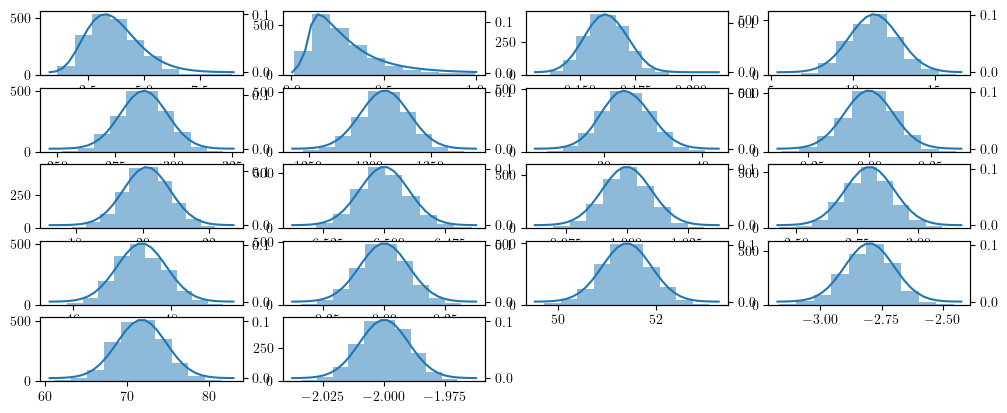

In [53]:
#tensors
TTCore = [None] * dim
for i in range(0,dim):
    TTCore[i] =  sirt.sirts[0].ftt.tt.cores[i]
    
absError = 1e-10
margPDFFull = getMargfromSQTT(TTCore, bounds, absError)

if True:
    #fig = plt.figure(figsize=plt.figaspect(0.4))
    fig = plt.figure(figsize=plt.figaspect(0.4))
    

    for i in range(0,18):
        axs = fig.add_subplot(5, 4, int(i+1))
        axs.hist(res.xs[:,i], alpha = alpha)
        axsT = axs.twinx()
        axsT.plot(univarGridFull[i], margPDFFull[i])
    
plt.show() 